In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import yaml
from helpers.data_transforms import  load_in_data


plt.style.use("../science.mplstyle")

In [2]:
BIN_BOUND = 5
NUM_BINS = 60
NUM_FEATURES = 5
NUM_BDTS = 10

COLS = [
    "InnerTrackerBarrelCollection",
  # "InnerTrackerEndcapCollection",
    "OuterTrackerBarrelCollection",     
 #   "OuterTrackerEndcapCollection",  
    "VertexBarrelCollection",   
  #  "VertexEndcapCollection",
]


feature_order_endcap = [0, 4, 1, 2, 3,  5, 6]
feature_indices_dict_endcap = {
    "r":2,
    "phi": 3,
    "z":4,
    "side":5,
    "layer":6
}

feature_order_barrel =[0, 4, 2, 3, 1,  5, 6]
feature_indices_dict_barrel = {
    "r":4,
    "phi": 2,
    "z":3,
    "side":5,
    "layer":6
}

feature_order_dict = {
     "InnerTrackerBarrelCollection":feature_order_barrel,
    "InnerTrackerEndcapCollection":feature_order_endcap,
    "OuterTrackerBarrelCollection":feature_order_barrel,
    "OuterTrackerEndcapCollection":feature_order_endcap,  
    "VertexBarrelCollection":feature_order_barrel,
    "VertexEndcapCollection":feature_order_endcap,

}


feature_indices_dict = {
     "InnerTrackerBarrelCollection":feature_indices_dict_barrel,
    "InnerTrackerEndcapCollection":feature_indices_dict_endcap,
    "OuterTrackerBarrelCollection":feature_indices_dict_barrel,
    "OuterTrackerEndcapCollection":feature_indices_dict_endcap,  
    "VertexBarrelCollection":feature_indices_dict_barrel,
    "VertexEndcapCollection":feature_indices_dict_endcap,

}


FEATURES = "rphi"
working_dir = "/pscratch/sd/r/rmastand/muon_collider"
log_vars = []



In [3]:
# load in samples

all_data_dir, all_samples_dir = {}, {}
bins_dict, bins_dict_preproc = {}, {}
aucs = {}
feature_labels_dict = {}

for col_name in COLS:

    small_id = ''.join([c for c in col_name if c.isupper()])
    X, feature_labels = load_in_data([col_name], FEATURES, working_dir, 1, 3, feature_order_dict[col_name])
    all_data_dir[col_name] = X[:]




In [4]:
x_dir = {col_name:[] for col_name in COLS}
y_dir = {col_name:[] for col_name in COLS}
z_dir = {col_name:[] for col_name in COLS}


for col_name in COLS:

    x_dir[col_name] = all_data_dir[col_name][:,feature_indices_dict[col_name]["r"]]*np.cos(all_data_dir[col_name][:,feature_indices_dict[col_name]["phi"]])
    y_dir[col_name] = all_data_dir[col_name][:,feature_indices_dict[col_name]["r"]]*np.sin(all_data_dir[col_name][:,feature_indices_dict[col_name]["phi"]])
    z_dir[col_name] = all_data_dir[col_name][:,feature_indices_dict[col_name]["z"]]

In [5]:
import numpy as np

# ── Constants ─────────────────────────────────────────────────────────────────
MODULE_HALF_LENGTH  = 15.05   # mm — tangential half-length of all barrel modules
HALF_SENSITIVE      = 0.050   # mm — half of 0.100mm sensitive Si layer

# ── Inner Tracker Barrel ──────────────────────────────────────────────────────
# rc = sensitive layer radius (DD4hep places sensor exactly at rc)
# nphi_half * 2 = total modules per layer (staggered double ring)
# dr = radial stagger between inner and outer ring

INNER_LAYERS = [
    {'rc': 127.0, 'nphi_half': 14, 'dr': 2.5},
    {'rc': 340.0, 'nphi_half': 38, 'dr': 2.5},
    {'rc': 554.0, 'nphi_half': 62, 'dr': 2.5},
]

def buildInnerTrackerBarrelModules():
    modules = []
    for layer in INNER_LAYERS:
        rc, nphi_half, dr = layer['rc'], layer['nphi_half'], layer['dr']
        nphi = nphi_half * 2
        for iphi in range(nphi):
            phi      = 2 * np.pi * iphi / nphi
            r_sensor = rc if iphi % 2 == 0 else rc + dr
            cx = r_sensor * np.cos(phi)
            cy = r_sensor * np.sin(phi)
            tx, ty = -np.sin(phi), np.cos(phi)
            modules.append({
                'x0': cx - MODULE_HALF_LENGTH * tx,
                'y0': cy - MODULE_HALF_LENGTH * ty,
                'x1': cx + MODULE_HALF_LENGTH * tx,
                'y1': cy + MODULE_HALF_LENGTH * ty,
            })
    return modules

# ── Outer Tracker Barrel ──────────────────────────────────────────────────────
# rc = module envelope centre (sensor offset must be computed from stack)
# drp/drm = radial stagger for even/odd phi modules
# sensor_offset = distance from module inner face to sensor centre
#   layers 0,1 use ModuleIn  (sensor near inner face, offset = 0.8015mm)
#   layer  2   uses ModuleOut (sensor near outer face, offset = 4.500mm)

OUTER_HALF_STACK = 5.303 / 2   # mm — half of total module stack thickness

OUTER_LAYERS = [
    {'rc': 819.0,  'nphi': 184, 'drp': 0.0, 'drm': 5.5, 'sensor_offset': 0.8015},
    {'rc': 1153.0, 'nphi': 256, 'drp': 0.0, 'drm': 5.5, 'sensor_offset': 0.8015},
    {'rc': 1486.0, 'nphi': 328, 'drp': 0.0, 'drm': 5.5, 'sensor_offset': 4.500},
]

def buildOuterTrackerBarrelModules():
    modules = []
    for layer in OUTER_LAYERS:
        rc   = layer['rc']
        nphi = layer['nphi']
        drp  = layer['drp']
        drm  = layer['drm']
        sensor_offset = layer['sensor_offset']
        for iphi in range(nphi):
            phi       = 2 * np.pi * iphi / nphi
            r_nominal = (rc - drp) if iphi % 2 == 0 else (rc + drm)
            r_sensor  = r_nominal - OUTER_HALF_STACK + sensor_offset
            cx = r_sensor * np.cos(phi)
            cy = r_sensor * np.sin(phi)
            tx, ty = -np.sin(phi), np.cos(phi)
            modules.append({
                'x0': cx - MODULE_HALF_LENGTH * tx,
                'y0': cy - MODULE_HALF_LENGTH * ty,
                'x1': cx + MODULE_HALF_LENGTH * tx,
                'y1': cy + MODULE_HALF_LENGTH * ty,
            })
    return modules

# ── Vertex Barrel ─────────────────────────────────────────────────────────────
# Flat ladder staves (ZSegmentedPlanarTracker)
# r = inner face of support; sensitive layer at r + SUPPORT_THICKNESS
# offset = tangential shift of stave centre from radial direction
# only innermost layer has a double-layer (inner + outer sensitive surface)

VERTEX_SUPPORT_THICKNESS  = 0.140  # mm
VERTEX_SENSITIVE_THICKNESS = 0.050  # mm
VERTEX_DOUBLELAYER_GAP     = 2.0    # mm

VERTEX_LAYERS = [
    {'r':  30.0, 'nstaves': 16, 'width': 13.0, 'offset': 2.0, 'double': True},
    {'r':  51.0, 'nstaves': 15, 'width': 23.0, 'offset': 2.0, 'double': False},
    {'r':  74.0, 'nstaves': 21, 'width': 24.0, 'offset': 2.0, 'double': False},
    {'r': 102.0, 'nstaves': 29, 'width': 24.0, 'offset': 2.0, 'double': False},
]

def buildVertexBarrelModules():
    modules = []
    for layer in VERTEX_LAYERS:
        r, nstaves, width, offset = layer['r'], layer['nstaves'], layer['width'], layer['offset']
        r_inner = r + VERTEX_SUPPORT_THICKNESS
        r_outer = r_inner + VERTEX_SENSITIVE_THICKNESS + VERTEX_DOUBLELAYER_GAP
        radii   = [r_inner, r_outer] if layer['double'] else [r_inner]
        half_w  = width / 2.0
        for r_sens in radii:
            for i in range(nstaves):
                phi    = 2 * np.pi * i / nstaves
                tx, ty = -np.sin(phi), np.cos(phi)
                cx = r_sens * np.cos(phi) + offset * tx
                cy = r_sens * np.sin(phi) + offset * ty
                modules.append({
                    'x0': cx - half_w * tx,
                    'y0': cy - half_w * ty,
                    'x1': cx + half_w * tx,
                    'y1': cy + half_w * ty,
                })
    return modules

# ── Build all ─────────────────────────────────────────────────────────────────
inner_modules  = buildInnerTrackerBarrelModules()
outer_modules  = buildOuterTrackerBarrelModules()
vertex_modules = buildVertexBarrelModules()

print(f"Inner tracker: {len(inner_modules)} modules")
print(f"Outer tracker: {len(outer_modules)} modules")
print(f"Vertex barrel: {len(vertex_modules)} modules")

# ── Mask function ─────────────────────────────────────────────────────────────
def make_barrel_mask(x, y, modules, corridor_width=HALF_SENSITIVE):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.zeros(len(x), dtype=bool)
    for m in modules:
        dx, dy = m['x1'] - m['x0'], m['y1'] - m['y0']
        len_sq = dx*dx + dy*dy
        t  = np.clip(((x - m['x0'])*dx + (y - m['y0'])*dy) / len_sq, 0, 1)
        px = m['x0'] + t*dx
        py = m['y0'] + t*dy
        mask |= (x - px)**2 + (y - py)**2 <= corridor_width**2
    return mask

Inner tracker: 228 modules
Outer tracker: 768 modules
Vertex barrel: 97 modules


In [6]:
def make_barrel_mask(x, y, modules, corridor_width):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.zeros(len(x), dtype=bool)
    for m in modules:
        dx, dy = m['x1'] - m['x0'], m['y1'] - m['y0']
        len_sq = dx*dx + dy*dy
        t  = np.clip(((x - m['x0'])*dx + (y - m['y0'])*dy) / len_sq, 0, 1)
        px = m['x0'] + t*dx
        py = m['y0'] + t*dy
        mask |= (x - px)**2 + (y - py)**2 <= corridor_width**2
    return mask






modules_dir = {

    "InnerTrackerBarrelCollection": buildInnerTrackerBarrelModules(),
    "OuterTrackerBarrelCollection": buildOuterTrackerBarrelModules(),
   "VertexBarrelCollection": buildVertexBarrelModules(),
}







In [7]:
def plot_barrel_overlay(x, y, modules, title, corridor_width, xlim, ylim, plot_modules = True):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # subsample hits for speed
    #idx = np.random.choice(len(x), min(max_hits, len(x)), replace=False)

    mask = make_barrel_mask(x, y, modules, corridor_width=corridor_width)

    fig, axes = plt.subplots(1, 2, figsize=(28, 7))

    for ax, show_mask, label in [
        (axes[0], False, 'all hits + modules'),
        (axes[1], True,  'kept (blue) / rejected (green)'),
    ]:
        if show_mask:
            #ax.scatter(x[idx][~mask[idx]], y[idx][~mask[idx]], s=0.5, c='orange',       alpha=0.3, label='rejected')
            #ax.scatter(x[idx][ mask[idx]], y[idx][ mask[idx]], s=0.5, c='steelblue', alpha=0.3, label='kept')
            ax.scatter(x[~mask], y[~mask], s=0.01, c='green',       alpha=1, label='rejected')
            ax.scatter(x[ mask], y[mask], s=0.01, c='steelblue', alpha=1, label='kept')
        else:
            #ax.scatter(x[idx], y[idx], s=0.5, c='steelblue', alpha=0.2)
            ax.scatter(x, y, s=0.01, c='steelblue', alpha=1)

        if plot_modules:
            for m in modules:
                # unit vector along segment
                dx = m['x1'] - m['x0']
                dy = m['y1'] - m['y0']
                length = np.sqrt(dx**2 + dy**2)
                tx, ty = dx / length, dy / length
                # perpendicular (normal) direction
                nx, ny = -ty, tx
    
                # four corners of the corridor rectangle
                corners = np.array([
                    [m['x0'] + nx * corridor_width, m['y0'] + ny * corridor_width],
                    [m['x1'] + nx * corridor_width, m['y1'] + ny * corridor_width],
                    [m['x1'] - nx * corridor_width, m['y1'] - ny * corridor_width],
                    [m['x0'] - nx * corridor_width, m['y0'] - ny * corridor_width],
                    [m['x0'] + nx * corridor_width, m['y0'] + ny * corridor_width],  # close
                ])
                ax.plot(corners[:, 0], corners[:, 1], 'r-', lw=0.5, alpha=1)



        r = np.sqrt(x**2 + y**2)
        kept_r    = np.sort(np.unique(r[mask].round(2)))
        rejected_r = np.sort(np.unique(r[~mask].round(2)))
        sensor_r   = np.sort(np.unique([round(np.sqrt(m['x0']**2+m['y0']**2),2) for m in modules]))
        
        print("kept r:    ", kept_r[:6])
        print("rejected r:", rejected_r[:6])
        print("sensor r:  ", sensor_r[:6])

        ax.set_aspect('equal')
        ax.set_title(f"{title}\n{label}")
 
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)

    plt.tight_layout()

    print(sum(mask), len(mask))
    
    plt.show()




kept r:     [126.97 126.98 126.99 127.   127.01 127.02]
rejected r: []
sensor r:   [127.89 130.37 340.33 342.83 554.2  556.7 ]
kept r:     [126.97 126.98 126.99 127.   127.01 127.02]
rejected r: []
sensor r:   [127.89 130.37 340.33 342.83 554.2  556.7 ]
3926196 3926196


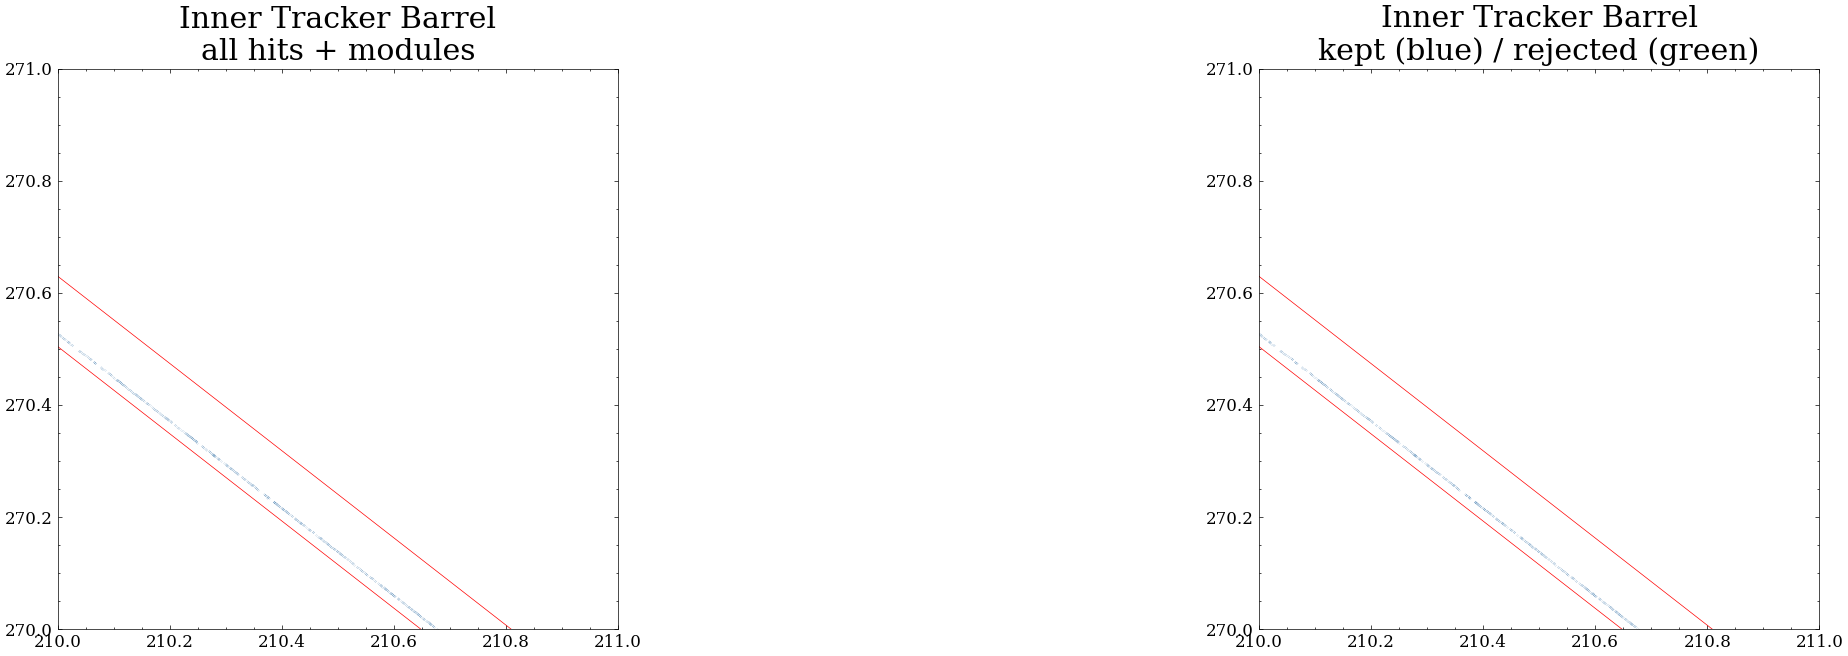

In [8]:

plot_barrel_overlay(x_dir['InnerTrackerBarrelCollection'],
                    y_dir['InnerTrackerBarrelCollection'],
                    modules_dir["InnerTrackerBarrelCollection"], 'Inner Tracker Barrel', corridor_width=0.99*HALF_SENSITIVE, 
                    xlim = (210,211), ylim = (270,271)) # 0.033 < x < 0.0325



kept r:     [817.15 817.16 817.17 817.18 817.19 817.2 ]
rejected r: []
sensor r:   [ 817.29  822.79 1151.25 1156.75 1487.92 1493.42]
kept r:     [817.15 817.16 817.17 817.18 817.19 817.2 ]
rejected r: []
sensor r:   [ 817.29  822.79 1151.25 1156.75 1487.92 1493.42]
3280678 3280678


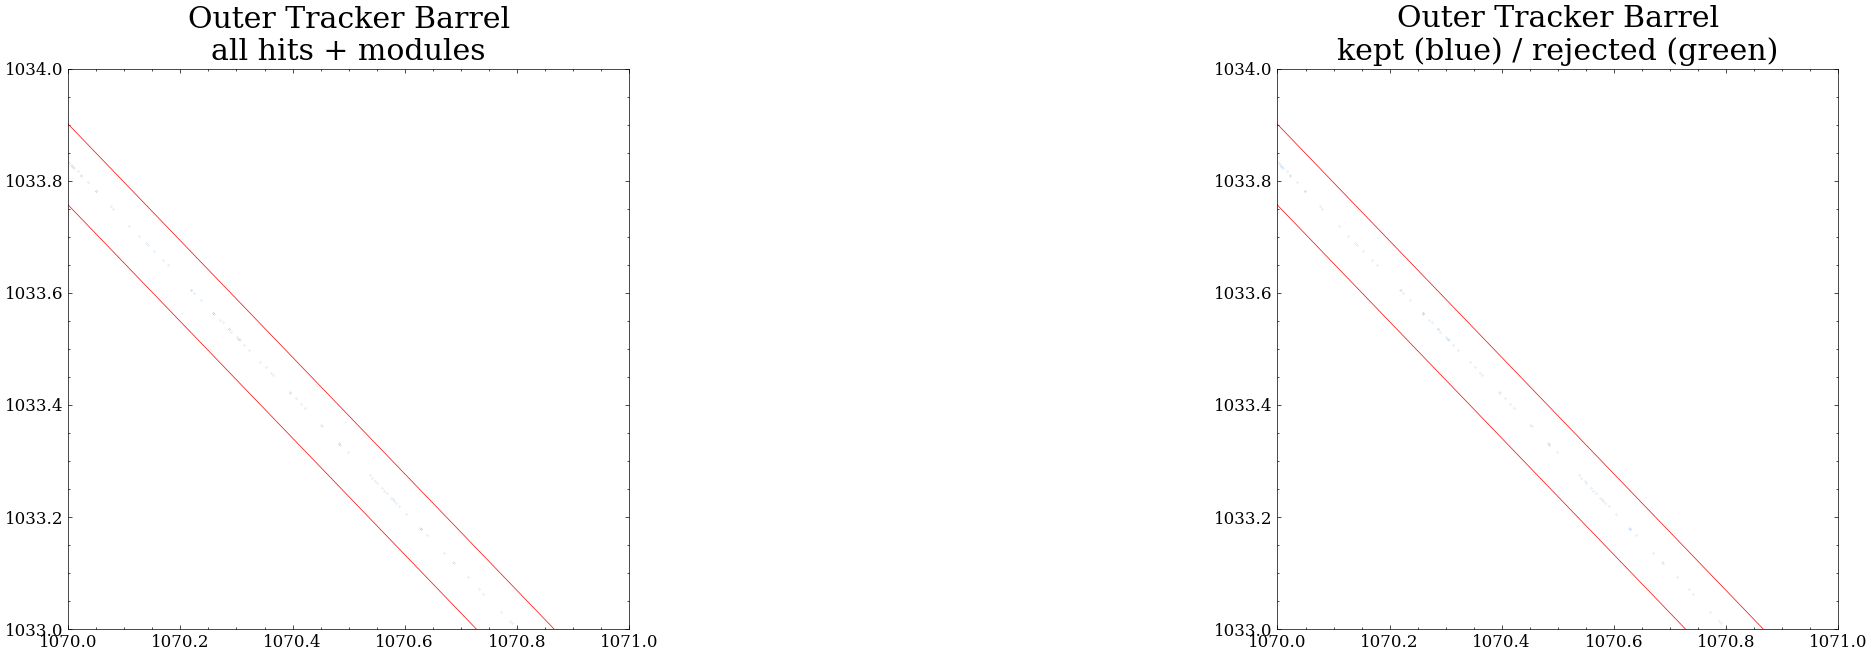

In [9]:




plot_barrel_overlay(x_dir['OuterTrackerBarrelCollection'],
                    y_dir['OuterTrackerBarrelCollection'],
                    modules_dir["OuterTrackerBarrelCollection"], 'Outer Tracker Barrel', corridor_width=HALF_SENSITIVE,
                   xlim = (1070,1071), ylim = (1033,1034), plot_modules = True)# 1.5 < x < 2



kept r:     [30.16 30.17 30.18 30.19 30.2  30.21]
rejected r: []
sensor r:   [ 30.47  32.5   52.01  74.81 102.63]
kept r:     [30.16 30.17 30.18 30.19 30.2  30.21]
rejected r: []
sensor r:   [ 30.47  32.5   52.01  74.81 102.63]
2129166 2129166


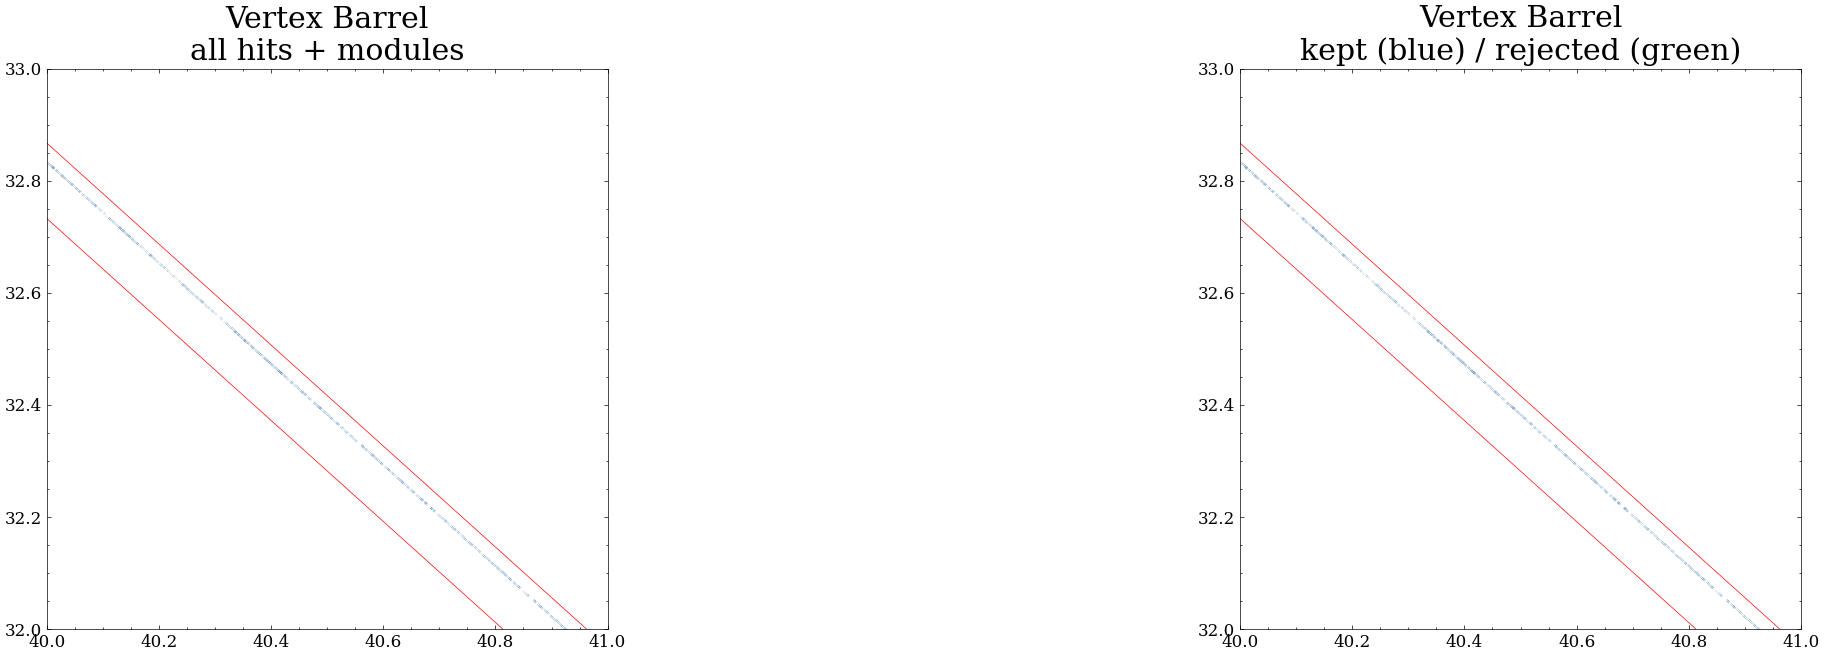

In [10]:
plot_barrel_overlay(x_dir['VertexBarrelCollection'],
                    y_dir['VertexBarrelCollection'],
                    modules_dir["VertexBarrelCollection"], 'Vertex Barrel', corridor_width=HALF_SENSITIVE, xlim = (40,41), ylim = (32,33), plot_modules=True) #0.01 < .1 